# 01 EDA: Hotel Booking Demand

**Purpose:** Senior-level exploratory analysis before any modelling decisions are made.

**Sections**
1. Setup and imports
2. Data integrity checks
3. Target variable construction
4. Cancellation analysis
5. Structural break and stationarity detection
6. Feature engineering hypotheses
7. Leakage audit
8. Distribution shift check (year-over-year)
9. Save processed data

**Source:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

## 1. Setup and Imports

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

RAW_PATH = '../data/raw/hotel_bookings.csv'
PROCESSED_PATH = '../data/processed/weekly_demand.csv'

df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')  # expect (119390, 32)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


## 2. Data Integrity Checks

Before trusting anything, verify the data is what it claims to be.
A senior engineer treats the raw file as untrusted until each check passes.

In [3]:
# --- 2a. Schema and types ---
print('=== DTYPES ===')
print(df.dtypes)
print(f'\nRow count: {len(df):,}')

=== DTYPES ===
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent              

In [4]:
# --- 2b. Null audit ---
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_report = null_report[null_report['null_count'] > 0].sort_values('null_pct', ascending=False)
print('=== COLUMNS WITH NULLS ===')
print(null_report)

=== COLUMNS WITH NULLS ===
          null_count  null_pct
company       112593     94.31
agent          16340     13.69
country          488      0.41
children           4      0.00


In [5]:
# --- 2c. Impossible values ---
print('=== IMPOSSIBLE VALUE CHECKS ===')
print(f'Negative ADR (price): {(df["adr"] < 0).sum()}')
print(f'Zero guests (adults+children+babies=0): {((df["adults"]+df["children"].fillna(0)+df["babies"]) == 0).sum()}')
print(f'Stays of 0 nights: {((df["stays_in_weekend_nights"]+df["stays_in_week_nights"]) == 0).sum()}')
print(f'Lead time < 0: {(df["lead_time"] < 0).sum()}')
print(f'ADR > 5000 (likely outlier): {(df["adr"] > 5000).sum()}')

=== IMPOSSIBLE VALUE CHECKS ===
Negative ADR (price): 1
Zero guests (adults+children+babies=0): 180
Stays of 0 nights: 715
Lead time < 0: 0
ADR > 5000 (likely outlier): 1


In [6]:
# --- 2d. Date range and continuity (vectorised - fast) ---
month_map = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}
df['month_num'] = df['arrival_date_month'].map(month_map)
df['arrival_date'] = pd.to_datetime(dict(
    year=df['arrival_date_year'],
    month=df['month_num'],
    day=df['arrival_date_day_of_month']
))
df.drop(columns='month_num', inplace=True)

print(f'Date range: {df["arrival_date"].min()} to {df["arrival_date"].max()}')
print(f'Unique years: {sorted(df["arrival_date_year"].unique())}')
print(f'Unique months: {df["arrival_date_month"].nunique()} (expect 12)')

Date range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00
Unique years: [2015, 2016, 2017]
Unique months: 12 (expect 12)


In [7]:
# --- 2e. Clean known data quality issues ---
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

zero_guest_mask = (df['adults'] + df['children'] + df['babies']) == 0
print(f'Dropping {zero_guest_mask.sum()} zero-guest records')
df = df[~zero_guest_mask].copy()

adr_mask = df['adr'] > 5000
print(f'Dropping {adr_mask.sum()} extreme ADR outlier(s)')
df = df[~adr_mask].copy()

print(f'\nClean shape: {df.shape}')

Dropping 180 zero-guest records
Dropping 1 extreme ADR outlier(s)

Clean shape: (119209, 33)


## 3. Target Variable Construction

The raw data is at booking level, not time-period level.
We define the forecasting target explicitly:

> **Target = weekly count of non-cancelled arrivals, aggregated by ISO week**

This is a deliberate modelling decision. We are forecasting actual arrivals,
not bookings made. Cancellations are treated separately in Section 4.

In [8]:
# Non-cancelled bookings only
arrivals = df[df['is_canceled'] == 0].copy()
print(f'Non-cancelled arrivals: {len(arrivals):,} ({len(arrivals)/len(df)*100:.1f}% of total)')

# Vectorised week start: subtract dayofweek to get Monday of each week
arrivals['iso_week'] = arrivals['arrival_date'] - pd.to_timedelta(
    arrivals['arrival_date'].dt.dayofweek, unit='D'
)
weekly = (
    arrivals.groupby('iso_week')
    .agg(bookings=('is_canceled', 'count'))
    .reset_index()
    .rename(columns={'iso_week': 'week_start'})
)
weekly = weekly.sort_values('week_start').reset_index(drop=True)
print(f'\nWeekly series: {len(weekly)} weeks')
print(f'From {weekly["week_start"].min()} to {weekly["week_start"].max()}')
weekly.head(10)

Non-cancelled arrivals: 75,011 (62.9% of total)

Weekly series: 114 weeks
From 2015-06-29 00:00:00 to 2017-08-28 00:00:00


,week_start,bookings
0,2015-06-29,258
1,2015-07-06,284
2,2015-07-13,377
3,2015-07-20,369
4,2015-07-27,330
5,2015-08-03,503
6,2015-08-10,644
7,2015-08-17,498
8,2015-08-24,458
9,2015-08-31,695


In [9]:
# --- Check for missing weeks (gaps in the time series) ---
all_weeks = pd.date_range(
    start=weekly['week_start'].min(),
    end=weekly['week_start'].max(),
    freq='W-MON'
)
missing_weeks = set(all_weeks) - set(weekly['week_start'])
print(f'Missing weeks in series: {len(missing_weeks)}')
if missing_weeks:
    print(sorted(missing_weeks))

Missing weeks in series: 0


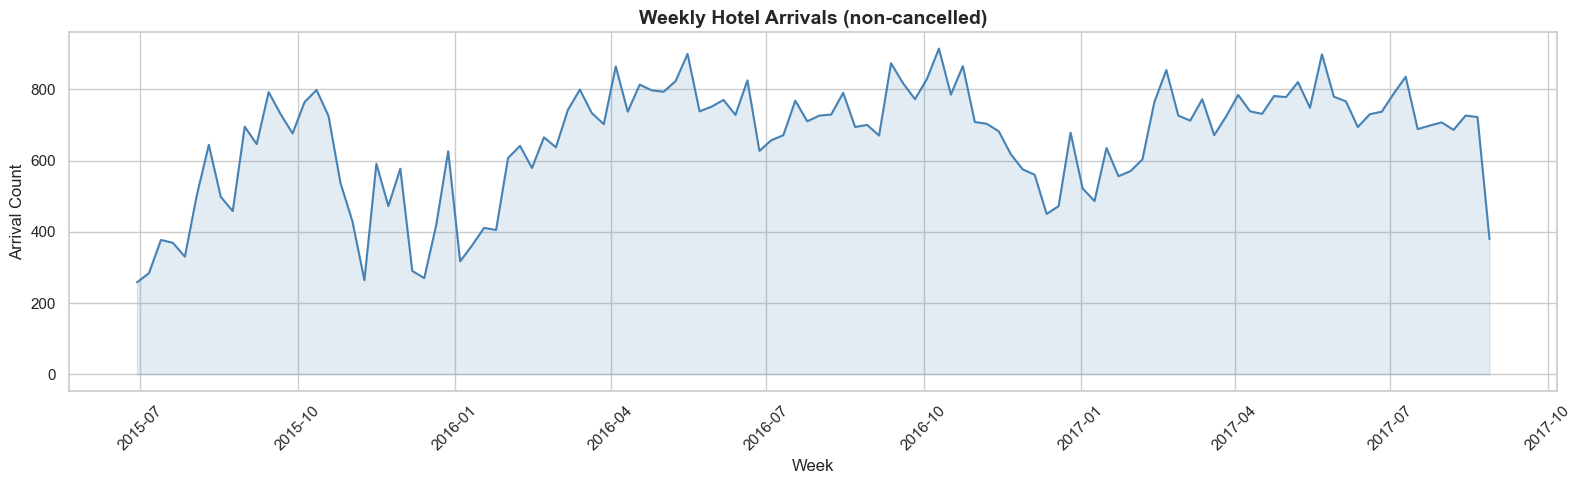


Descriptive stats:
count   114.00
mean    657.99
std     157.98
min     258.00
25%     577.50
50%     702.50
75%     769.50
max     914.00
Name: bookings, dtype: float64


In [10]:
# --- Plot the weekly demand series ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly['week_start'], weekly['bookings'], linewidth=1.5, color='steelblue')
ax.fill_between(weekly['week_start'], weekly['bookings'], alpha=0.15, color='steelblue')
ax.set_title('Weekly Hotel Arrivals (non-cancelled)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Arrival Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'\nDescriptive stats:')
print(weekly['bookings'].describe())

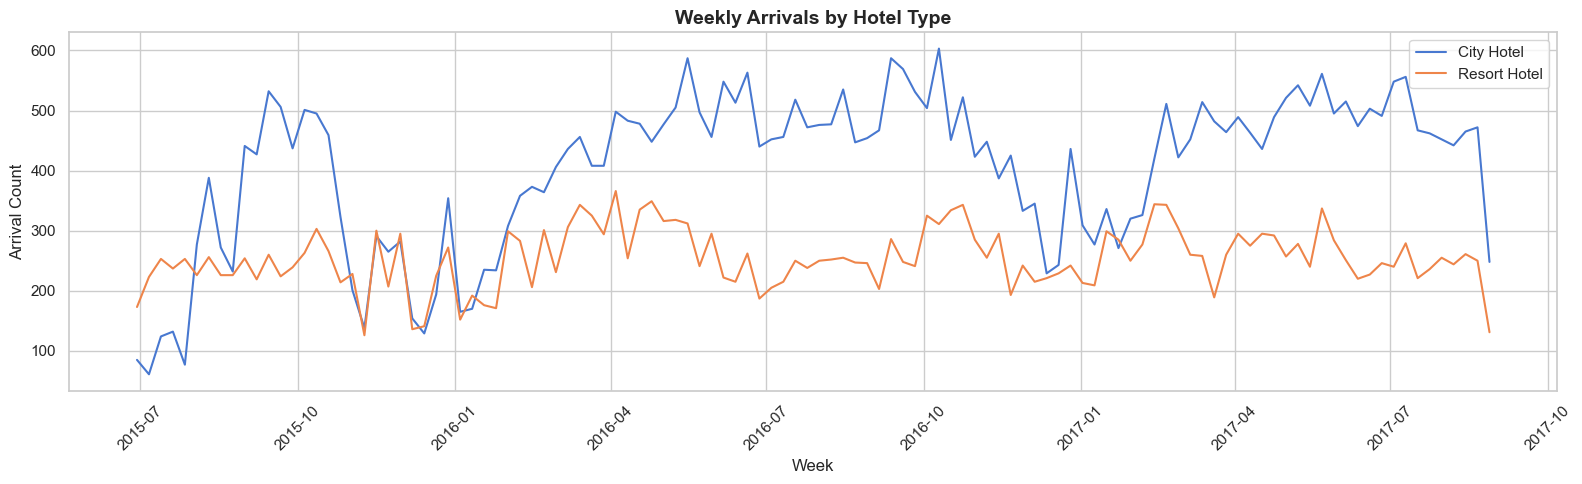

In [11]:
# --- Split by hotel type: City vs Resort ---
weekly_by_hotel = (
    arrivals.groupby(['iso_week', 'hotel'])
    .agg(bookings=('is_canceled', 'count'))
    .reset_index()
    .rename(columns={'iso_week': 'week_start'})
)

fig, ax = plt.subplots(figsize=(16, 5))
for hotel, grp in weekly_by_hotel.groupby('hotel'):
    ax.plot(grp['week_start'], grp['bookings'], label=hotel, linewidth=1.5)
ax.set_title('Weekly Arrivals by Hotel Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Arrival Count')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Cancellation Analysis

Cancellations are not noise — they are a signal.
High cancellation rates in certain segments mean gross bookings are a poor
proxy for actual demand. We analyse them as a separate dimension.

In [12]:
cancel_rate = df['is_canceled'].mean()
print(f'Overall cancellation rate: {cancel_rate:.1%}')

print('\nCancellation rate by hotel type:')
print(df.groupby('hotel')['is_canceled'].mean().map('{:.1%}'.format))

Overall cancellation rate: 37.1%

Cancellation rate by hotel type:
hotel
City Hotel      41.8%
Resort Hotel    27.8%
Name: is_canceled, dtype: object


In [13]:
# By market segment
cancel_by_segment = (
    df.groupby('market_segment')['is_canceled']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'cancel_rate', 'count': 'n_bookings'})
    .sort_values('cancel_rate', ascending=False)
)
cancel_by_segment['cancel_rate'] = cancel_by_segment['cancel_rate'].map('{:.1%}'.format)
print('Cancellation rate by market segment:')
print(cancel_by_segment)

Cancellation rate by market segment:
               cancel_rate  n_bookings
market_segment                        
Undefined           100.0%           2
Groups               61.1%       19791
Online TA            36.8%       56408
Offline TA/TO        34.3%       24181
Aviation             22.1%         235
Corporate            18.8%        5282
Direct               15.4%       12582
Complementary        12.2%         728


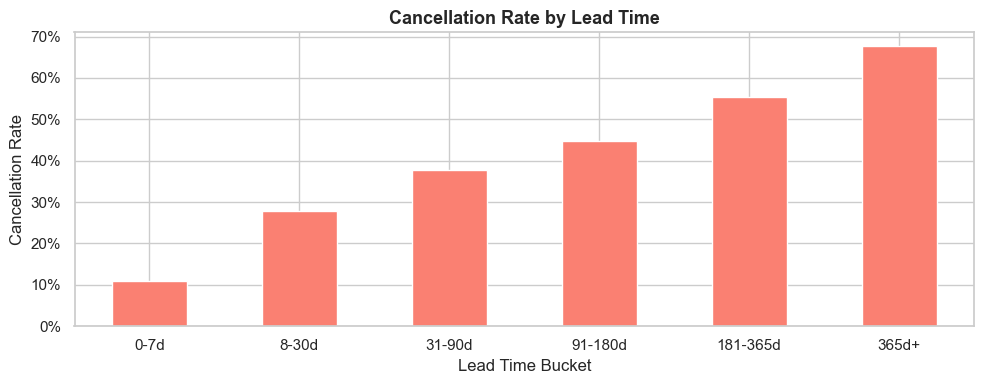

In [14]:
# Cancellation rate vs lead time (binned)
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=[0,7,30,90,180,365,750],
                              labels=['0-7d','8-30d','31-90d','91-180d','181-365d','365d+'])
cancel_by_lead = df.groupby('lead_time_bin', observed=True)['is_canceled'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
cancel_by_lead.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Cancellation Rate by Lead Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Lead Time Bucket')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

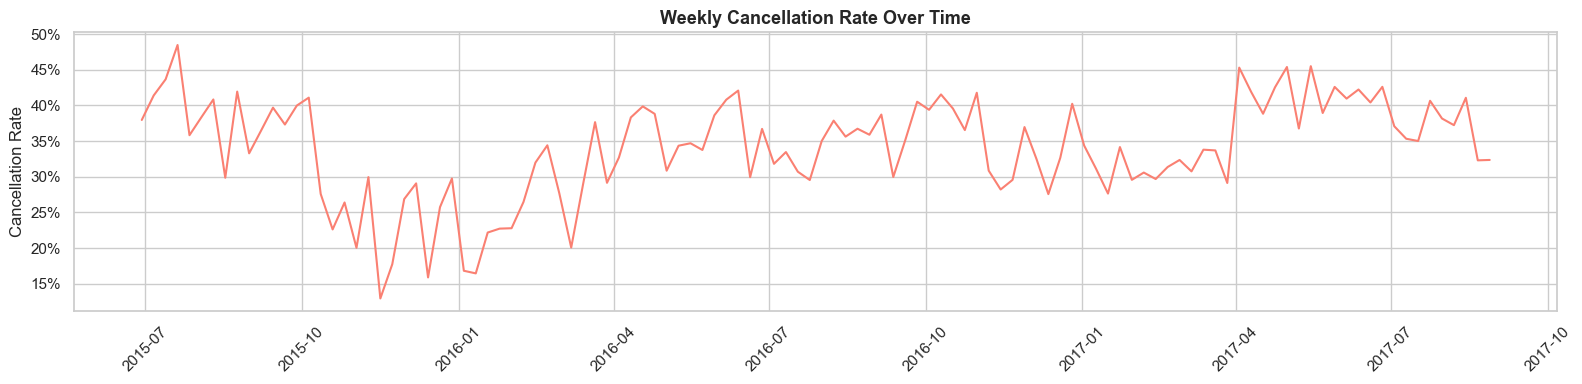

In [15]:
# Weekly cancellation rate over time (vectorised)
weekly_cancel = (
    df.groupby('arrival_date')
    .agg(cancel_rate=('is_canceled', 'mean'))
    .reset_index()
)
weekly_cancel['week'] = weekly_cancel['arrival_date'] - pd.to_timedelta(
    weekly_cancel['arrival_date'].dt.dayofweek, unit='D'
)
weekly_cancel_agg = weekly_cancel.groupby('week')['cancel_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(weekly_cancel_agg['week'], weekly_cancel_agg['cancel_rate'], color='salmon', linewidth=1.5)
ax.set_title('Weekly Cancellation Rate Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Structural Break and Stationarity Detection

Before choosing a model, test whether the series is stationary and whether
there are structural breaks. This determines whether Prophet (handles trend
and seasonality natively) or a differenced LightGBM approach is more appropriate.

In [16]:
# Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(weekly['bookings'].dropna(), autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Lags used     : {adf_result[2]}')
print(f'Obs used      : {adf_result[3]}')
for key, val in adf_result[4].items():
    print(f'Critical ({key}): {val:.4f}')
print()
if adf_result[1] < 0.05:
    print('RESULT: Series is stationary (reject unit root hypothesis)')
else:
    print('RESULT: Series is NOT stationary (fail to reject unit root) -> consider differencing')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -3.0237
p-value       : 0.0327
Lags used     : 6
Obs used      : 107
Critical (1%): -3.4930
Critical (5%): -2.8890
Critical (10%): -2.5814

RESULT: Series is stationary (reject unit root hypothesis)


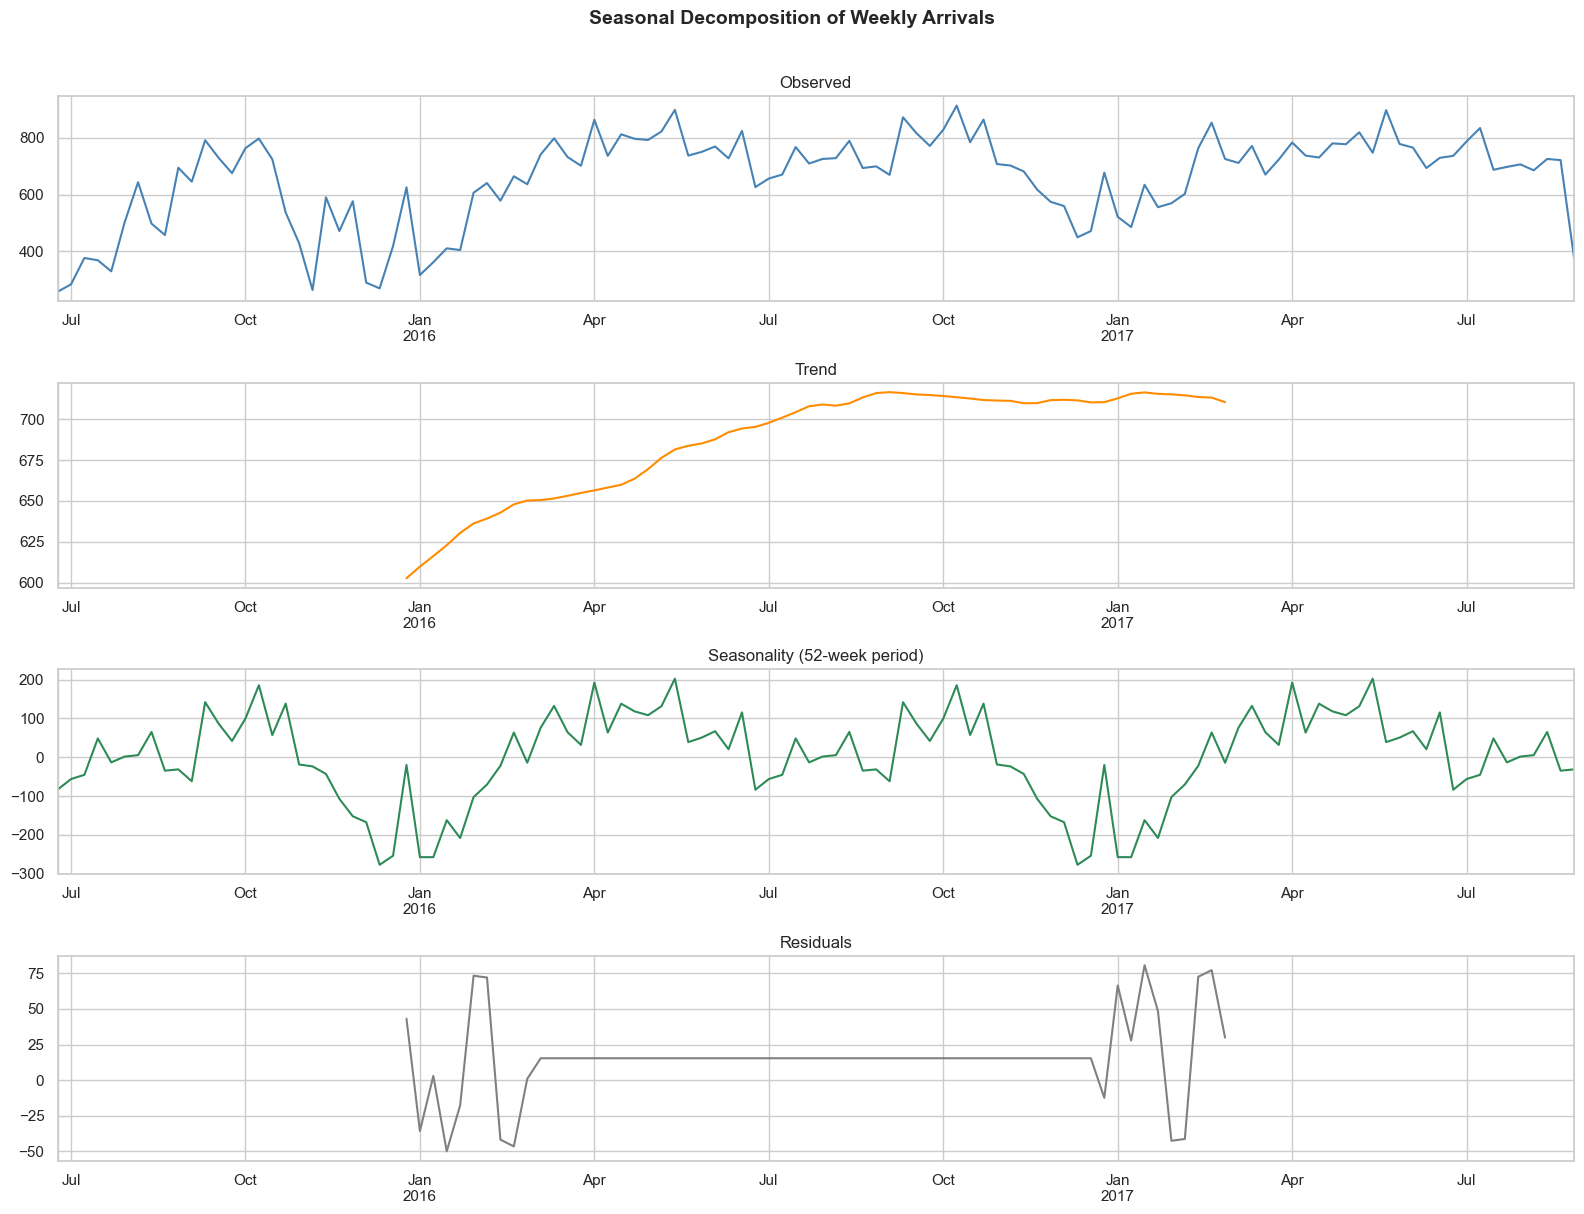

In [17]:
# Seasonal decomposition
weekly_indexed = weekly.set_index('week_start')['bookings']
decomp = seasonal_decompose(weekly_indexed, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomp.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Trend', color='darkorange')
decomp.seasonal.plot(ax=axes[2], title='Seasonality (52-week period)', color='seagreen')
decomp.resid.plot(ax=axes[3], title='Residuals', color='grey')
for ax in axes:
    ax.set_xlabel('')
plt.suptitle('Seasonal Decomposition of Weekly Arrivals', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

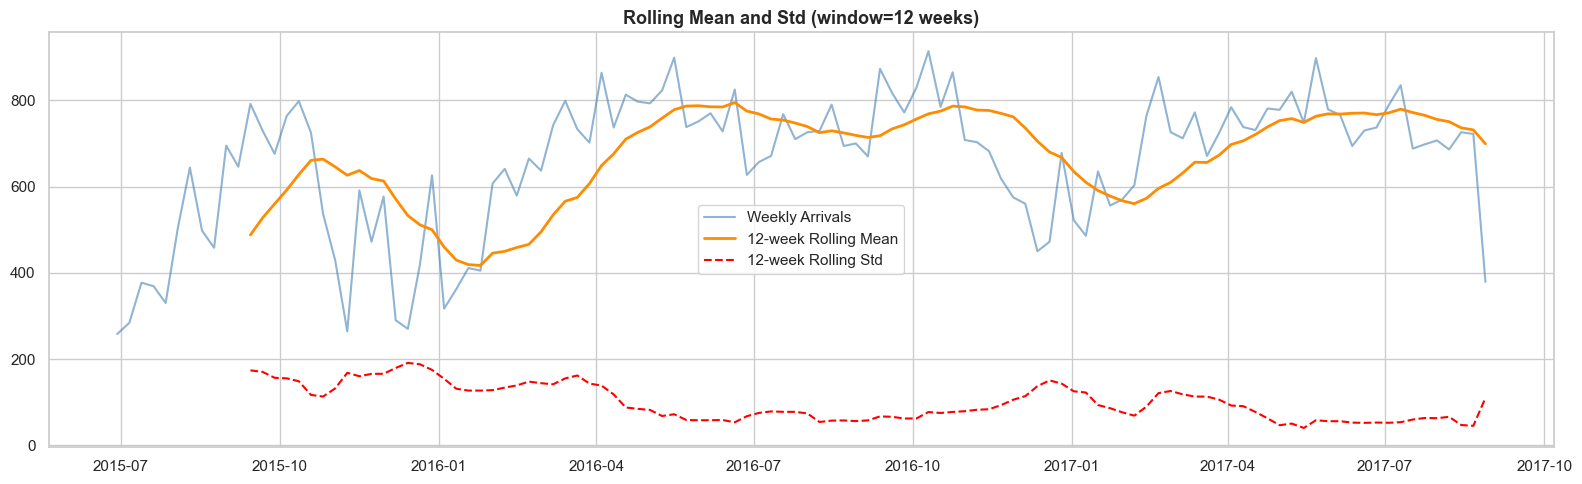

In [18]:
# Rolling mean and std
rolling_mean = weekly_indexed.rolling(window=12).mean()
rolling_std = weekly_indexed.rolling(window=12).std()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_indexed, label='Weekly Arrivals', color='steelblue', alpha=0.6)
ax.plot(rolling_mean, label='12-week Rolling Mean', color='darkorange', linewidth=2)
ax.plot(rolling_std, label='12-week Rolling Std', color='red', linewidth=1.5, linestyle='--')
ax.set_title('Rolling Mean and Std (window=12 weeks)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Engineering Hypotheses

A senior engineer forms hypotheses before running correlations, then tests each one.

| Hypothesis | Feature | Expected relationship |
|---|---|---|
| H1 | `arrival_date_month` | Strong seasonal effect — summer peak |
| H2 | `lead_time` | Longer lead time -> higher cancellation risk |
| H3 | `market_segment` | OTA bookings more volatile than direct |
| H4 | `adr` | Price signal — peaks in high season |
| H5 | `is_repeated_guest` | Loyal guests less likely to cancel |
| H6 | `country` | Domestic vs international has seasonal pattern |

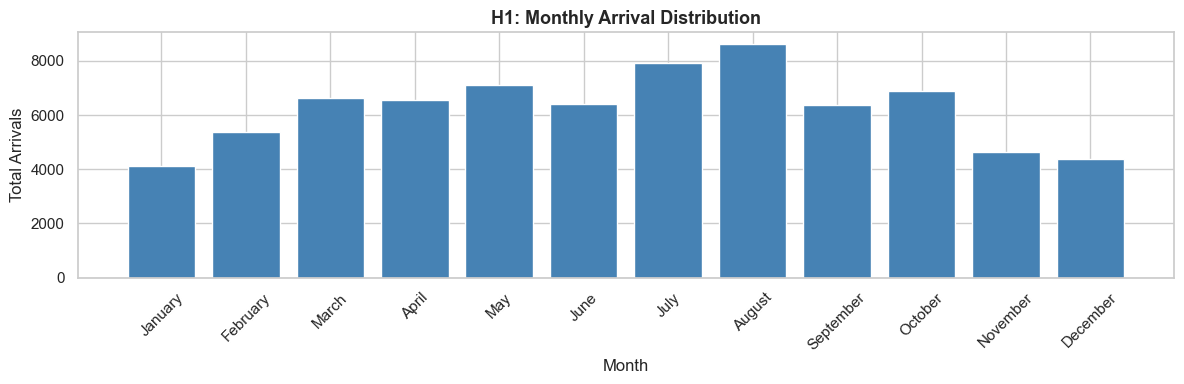

In [19]:
# H1: Monthly seasonality
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_arrivals = (
    arrivals.groupby('arrival_date_month')
    .size()
    .reindex(month_order)
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_arrivals['arrival_date_month'], monthly_arrivals['count'],
       color='steelblue', edgecolor='white')
ax.set_title('H1: Monthly Arrival Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Arrivals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

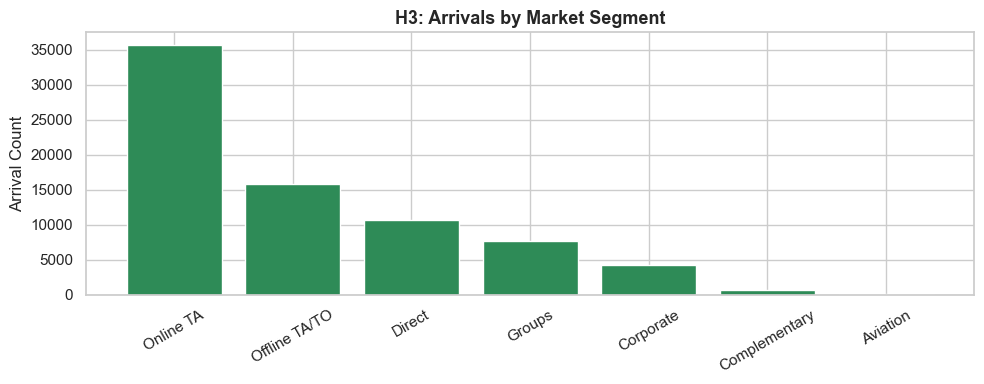

In [20]:
# H3: Volume by market segment
segment_volume = (
    arrivals.groupby('market_segment')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(segment_volume['market_segment'], segment_volume['count'],
       color='seagreen', edgecolor='white')
ax.set_title('H3: Arrivals by Market Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Arrival Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

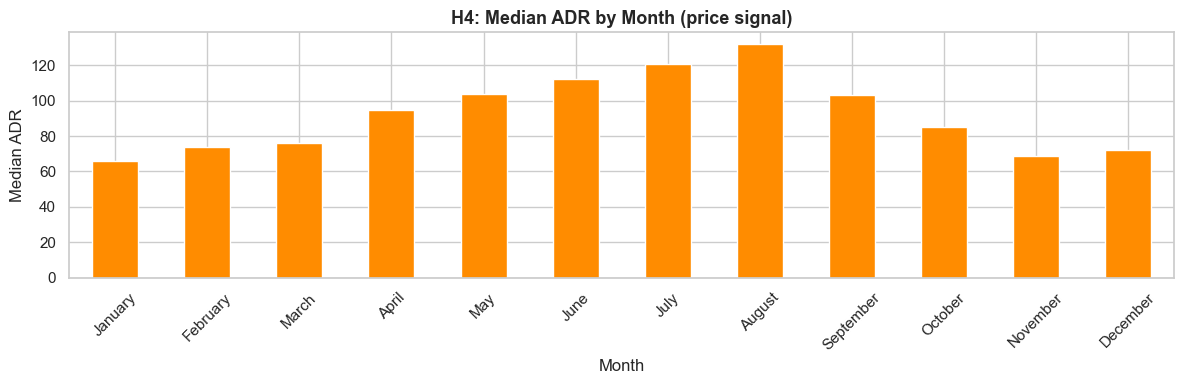

In [21]:
# H4: Median ADR by month
fig, ax = plt.subplots(figsize=(12, 4))
arrivals.groupby('arrival_date_month')['adr'].median().reindex(month_order).plot(
    kind='bar', ax=ax, color='darkorange', edgecolor='white'
)
ax.set_title('H4: Median ADR by Month (price signal)', fontsize=13, fontweight='bold')
ax.set_ylabel('Median ADR')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# H5: Repeat guest cancellation rate
repeat_cancel = df.groupby('is_repeated_guest')['is_canceled'].mean()
print('H5: Cancellation rate by repeat guest status')
print(repeat_cancel.rename(index={0: 'New guest', 1: 'Repeat guest'}).map('{:.1%}'.format))

H5: Cancellation rate by repeat guest status
is_repeated_guest
New guest       37.8%
Repeat guest    14.6%
Name: is_canceled, dtype: object


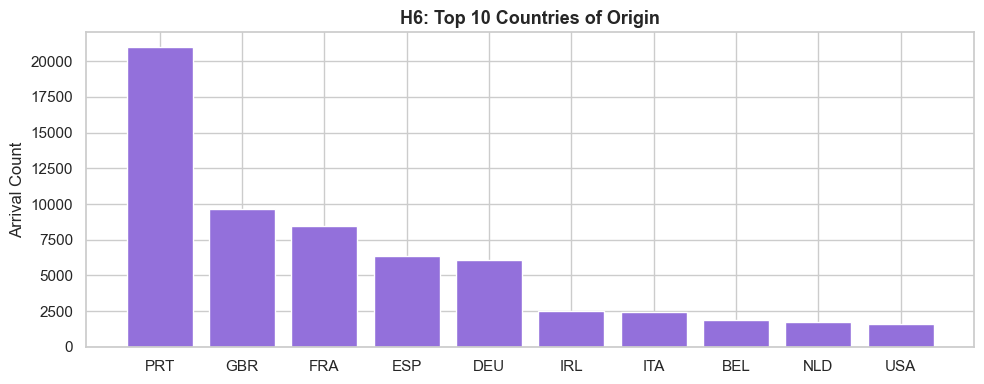

In [23]:
# H6: Top 10 countries by volume
top_countries = (
    arrivals.groupby('country')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_countries['country'], top_countries['count'], color='mediumpurple', edgecolor='white')
ax.set_title('H6: Top 10 Countries of Origin', fontsize=13, fontweight='bold')
ax.set_ylabel('Arrival Count')
plt.tight_layout()
plt.show()

## 7. Leakage Audit

Every feature candidate must pass the leakage test:
> Would this value be available at the time we make the prediction?

We are predicting demand 1-4 weeks ahead. The prediction is made at week T.
Features must only use information available at week T or earlier.

In [24]:
leakage_audit = pd.DataFrame([
    {'feature': 'arrival_date_month',       'available_at_T': True,  'reason': 'Known from the date itself'},
    {'feature': 'arrival_date_week_number', 'available_at_T': True,  'reason': 'Known from the date itself'},
    {'feature': 'lead_time',                'available_at_T': False, 'reason': 'Set at booking time, not arrival time'},
    {'feature': 'is_canceled',              'available_at_T': False, 'reason': 'Outcome variable — never use as feature'},
    {'feature': 'reservation_status',       'available_at_T': False, 'reason': 'Set after arrival — hard leakage'},
    {'feature': 'reservation_status_date',  'available_at_T': False, 'reason': 'Set after arrival — hard leakage'},
    {'feature': 'adr',                      'available_at_T': False, 'reason': 'Final ADR may change after booking'},
    {'feature': 'market_segment',           'available_at_T': True,  'reason': 'Known at booking time, can aggregate weekly'},
    {'feature': 'hotel',                    'available_at_T': True,  'reason': 'Known'},
    {'feature': 'is_repeated_guest',        'available_at_T': True,  'reason': 'Known at booking time'},
    {'feature': 'booking_changes',          'available_at_T': False, 'reason': 'Accumulates up to arrival — leakage risk'},
    {'feature': 'days_in_waiting_list',     'available_at_T': False, 'reason': 'Post-booking attribute'},
    {'feature': 'lag_1_week_bookings',      'available_at_T': True,  'reason': 'Engineered lag feature — safe'},
    {'feature': 'lag_4_week_bookings',      'available_at_T': True,  'reason': 'Engineered lag feature — safe'},
    {'feature': 'rolling_4w_mean',          'available_at_T': True,  'reason': 'Rolling window on past data — safe'},
])

print('=== LEAKAGE AUDIT ===')
print(leakage_audit.to_string(index=False))

=== LEAKAGE AUDIT ===
                 feature  available_at_T                                      reason
      arrival_date_month            True                  Known from the date itself
arrival_date_week_number            True                  Known from the date itself
               lead_time           False       Set at booking time, not arrival time
             is_canceled           False     Outcome variable — never use as feature
      reservation_status           False            Set after arrival — hard leakage
 reservation_status_date           False            Set after arrival — hard leakage
                     adr           False          Final ADR may change after booking
          market_segment            True Known at booking time, can aggregate weekly
                   hotel            True                                       Known
       is_repeated_guest            True                       Known at booking time
         booking_changes           False   

## 8. Distribution Shift Check (Year-over-Year)

If distributions shift significantly between years, models trained on one
year will degrade on the next. This motivates the PSI drift monitoring
built into this platform.

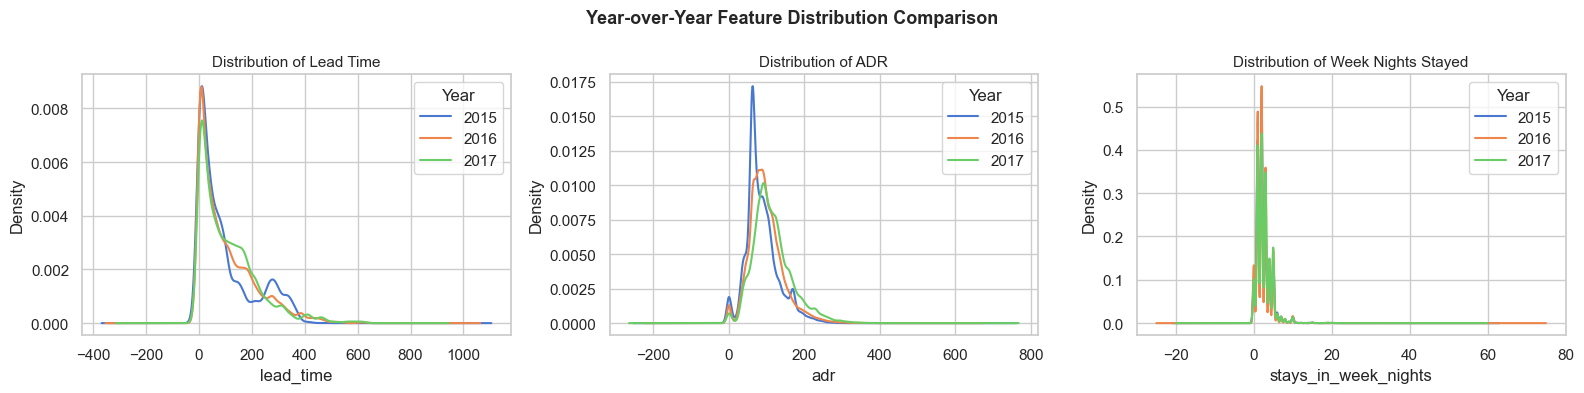

In [25]:
years = sorted(df['arrival_date_year'].unique())
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes,
                           ['lead_time', 'adr', 'stays_in_week_nights'],
                           ['Lead Time', 'ADR', 'Week Nights Stayed']):
    for year in years:
        subset = df[df['arrival_date_year'] == year][col].dropna()
        subset.plot(kind='density', ax=ax, label=str(year), linewidth=1.5)
    ax.set_title(f'Distribution of {title}', fontsize=11)
    ax.set_xlabel(col)
    ax.legend(title='Year')

plt.suptitle('Year-over-Year Feature Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
def compute_psi(expected, actual, buckets=10):
    """Compute Population Stability Index between two distributions."""
    breakpoints = np.linspace(0, 100, buckets + 1)
    expected_pcts = np.unique(np.percentile(expected, breakpoints))

    def bucket_series(s, bp):
        counts = np.histogram(s, bins=bp)[0]
        pcts = counts / len(s)
        return np.where(pcts == 0, 0.0001, pcts)

    e = bucket_series(expected, expected_pcts)
    a = bucket_series(actual, expected_pcts)
    n = min(len(e), len(a))
    return np.sum((a[:n] - e[:n]) * np.log(a[:n] / e[:n]))

if len(years) >= 2:
    base = df[df['arrival_date_year'] == years[0]]['lead_time'].dropna().values
    for yr in years[1:]:
        compare = df[df['arrival_date_year'] == yr]['lead_time'].dropna().values
        psi_val = compute_psi(base, compare)
        flag = '<<< DRIFT DETECTED' if psi_val > 0.2 else 'OK'
        print(f'PSI lead_time ({years[0]} vs {yr}): {psi_val:.4f}  {flag}')
print('\nPSI thresholds: < 0.1 = stable, 0.1-0.2 = slight shift, > 0.2 = significant drift')

PSI lead_time (2015 vs 2016): 0.0557  OK
PSI lead_time (2015 vs 2017): 0.1262  OK

PSI thresholds: < 0.1 = stable, 0.1-0.2 = slight shift, > 0.2 = significant drift


## 9. Save Processed Data

In [27]:
weekly.to_csv(PROCESSED_PATH, index=False)
print(f'Saved weekly demand series to {PROCESSED_PATH}')
print(f'Shape: {weekly.shape}')
weekly.tail()

Saved weekly demand series to ../data/processed/weekly_demand.csv
Shape: (114, 2)


,week_start,bookings
109,2017-07-31,707
110,2017-08-07,686
111,2017-08-14,726
112,2017-08-21,722
113,2017-08-28,379


In [28]:
clean_path = '../data/processed/hotel_bookings_clean.csv'
df.to_csv(clean_path, index=False)
print(f'Saved clean booking data to {clean_path}')
print(f'Shape: {df.shape}')

Saved clean booking data to ../data/processed/hotel_bookings_clean.csv
Shape: (119209, 34)


## EDA Summary and Modelling Decisions

| Finding | Modelling Decision |
|---|---|
| Strong annual seasonality | Prophet additive seasonality, LightGBM week-of-year feature |
| City and Resort have different patterns | Train combined model with `hotel` as a feature; evaluate per-segment metrics |
| Overall cancellation rate ~37% | Forecast net arrivals (non-cancelled); monitor cancellation rate separately |
| Lead time strongly predicts cancellation | Include weekly average lead time as a lag feature |
| `reservation_status` and `is_canceled` would leak | Excluded from all feature sets |
| Distribution stable across years | PSI monitoring threshold set at 0.2 (already in drift_detector.py) |

**Next step:** Open `src/features/build_features.py` and implement the lag and calendar features identified here.